In this notebook we take a look at the performance of our simulation models (single- and multi-comparment) at initialization. We want to see how many of 3000 models with random parameters spike at all, and how close they are to the experimental data. We test our 1. full single-compartment model, 2. without H() channels, 3. without H() and M() channels, 4. without H(), M(), and Ca() channels, and 5. the full multi-compartment model.

Note: I ran this with the original bounds bounds["NaTs2T_gNaTs2T"] = [0.0, 6.0], bounds["SKv3_1_gSKv3_1"] = [0.25, 1.0] instead of the slightly modified bounds of bounds["NaTs2T_gNaTs2T"] = [0.0, 1.0] and bounds["SKv3_1_gSKv3_1"] = [0.01, 0.5].

In [28]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2



from jax import config
config.update("jax_enable_x64", True)


import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

from voltage_fitting.posthoc_summary_stats import (
    find_spikes,
    spike_count,
    first_spike_time,
    second_spike_time,
    first_spike_amp,
    second_spike_amp,
)

from voltage_fitting.loss_util import (
    get_scaled_loss,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
t_max = 250.0
cut = 1500

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data,
)
t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

time_vec = np.arange(0, t_max+2*0.025, 0.025)
time_vec = time_vec[cut:]

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


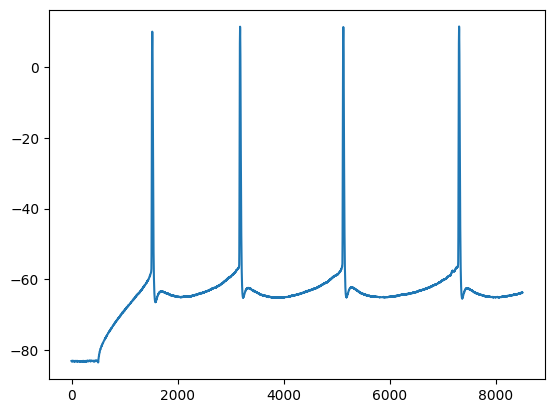

In [30]:
plt.plot(v_data[0])

**Full single-compartment model**

In [31]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0])[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


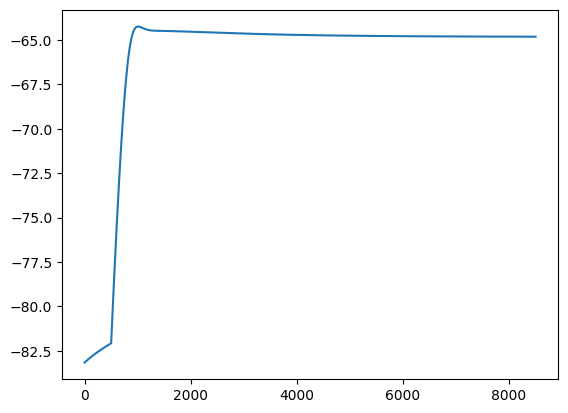

In [32]:
# One random simulation
plt.plot(v_single[0])

In [33]:
# Simulate 3000 times with random parameters

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])

n_params = 3_000
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_params)
)

def predict(params):
    inv_params = inv_transform_params(params)
    simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0])[0][0]
    return v

vmapped_predict = jax.vmap(predict)
x_pred_full = vmapped_predict(opt_params)

_ = np.random.seed(0)
noise = np.random.randn(len(v_data[0])) * 1e-2

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

v_data_spikes = find_spikes(v_data[0] + noise, None, None, thr)
v_data_ss = {
    "spike_count": spike_count(v_data_spikes),
    "first_spike_time": first_spike_time(v_data_spikes),
    "second_spike_time": second_spike_time(v_data_spikes),
    "first_spike_amp": first_spike_amp(v_data[0], v_data_spikes),
    "second_spike_amp": second_spike_amp(v_data[0], v_data_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_pred_full, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_pred_full, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_pred_full, pred_spikes)]
    ),
}

errors = {}
for key in v_data_ss.keys():
    errors[key] = np.abs(v_data_ss[key] - pred_ss[key])

# Weigh the individusal errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)


vmapped_scaled_dtw_loss = jax.vmap(get_scaled_loss, in_axes=(None, 0, None, None, None))
scaled_dtw_errors = vmapped_scaled_dtw_loss(v_data[0], x_pred_full, 1.0, 0.05, 1.0)#, cost_fn_power=1.0, scale=0.05, penalty_rate=1.0)
scaled_dtw_errors_squared = vmapped_scaled_dtw_loss(v_data[0], x_pred_full, 2.0, 1.0, 0.0)#, cost_fn_power=2.0, scale=1.0, penalty_rate=0.0)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [34]:
summed_errors[:100]

array([397.86985521, 876.40625   , 876.40625   , 550.3566634 ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 540.78024367,
       876.40625   , 876.40625   , 563.72240149, 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 555.22303568,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 541.34948294, 876.40625   , 256.63433673,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 355.09608828,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40

In [35]:
count = jnp.sum(summed_errors < 876.40625) # 876.40625 is the loss of flat predictions
print(count, "spiking models found")

458 spiking models found


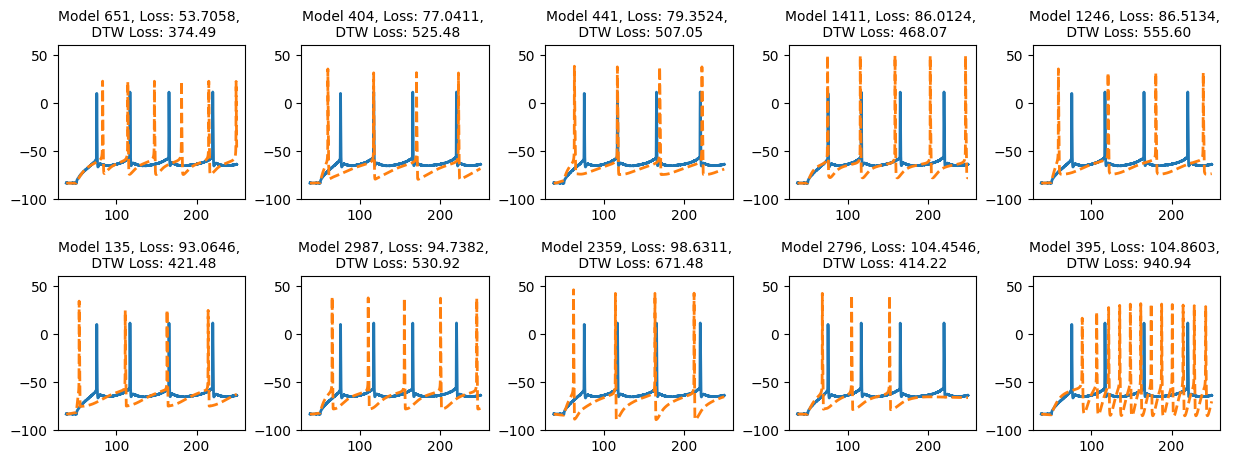

In [39]:
# 10 best results based on summed errors
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred_full[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

np.save("../results/single_summed_errors.npy", summed_errors)
np.save("../results/single_preds.npy", x_pred_full)

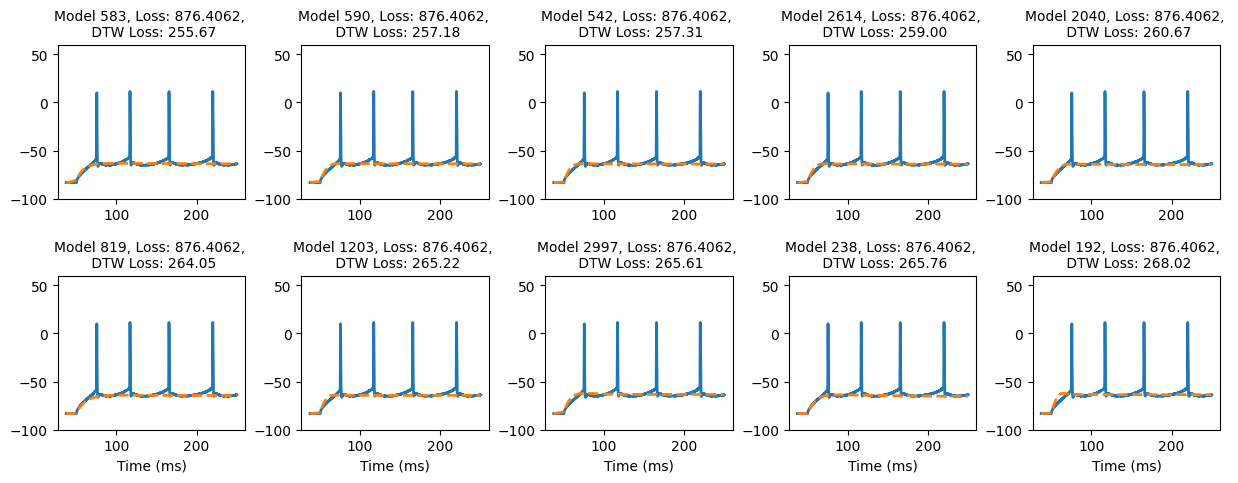

In [40]:
# 10 best results based on dtw loss
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred_full[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")
    
np.save("../results/single_dtw_errors.npy", scaled_dtw_errors)

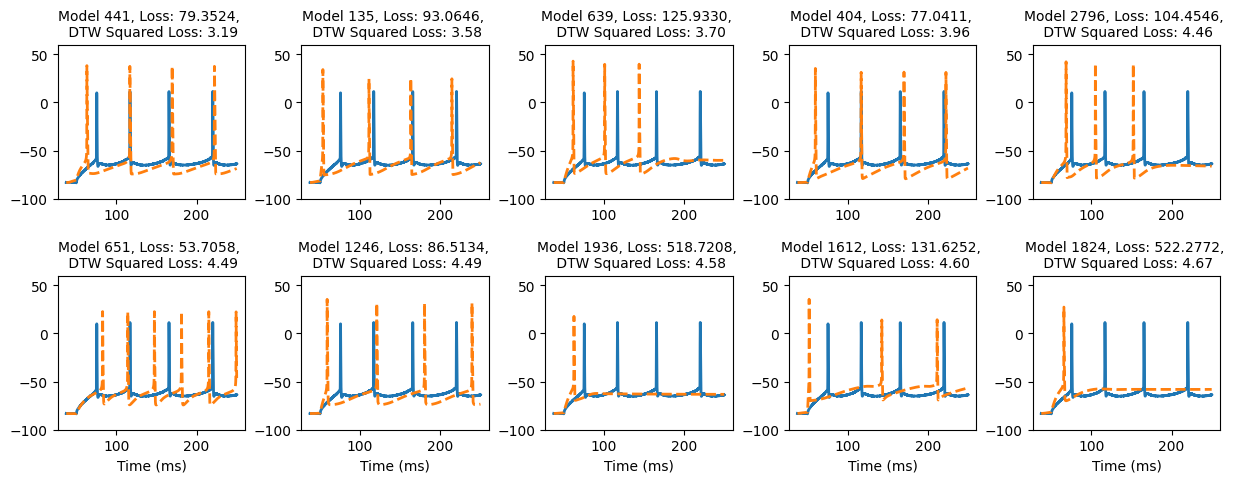

In [41]:
# 10 best results based on squared dtw loss
inds = np.argsort(scaled_dtw_errors_squared)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred_full[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Squared Loss: {scaled_dtw_errors_squared[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

Text(0.5, 0, 'Time (ms)')

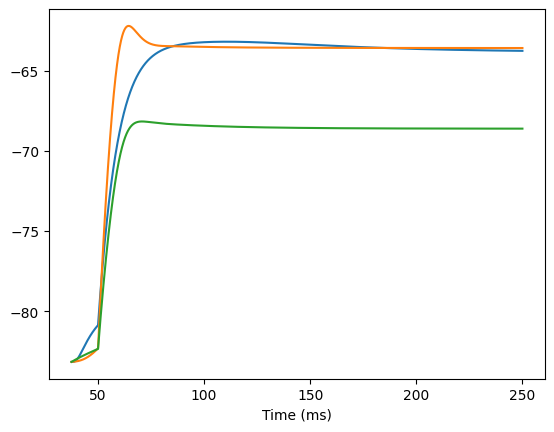

In [43]:
# What is the difference between flat models that give different dtw losses? - the height
plt.plot(time_vec, x_pred_full[583])
plt.plot(time_vec, x_pred_full[192])
plt.plot(time_vec, x_pred_full[1])
plt.xlabel("Time (ms)")

**Single-compartment model Without H() channel**

In [44]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], include_H = False)
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0], include_H = False)[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


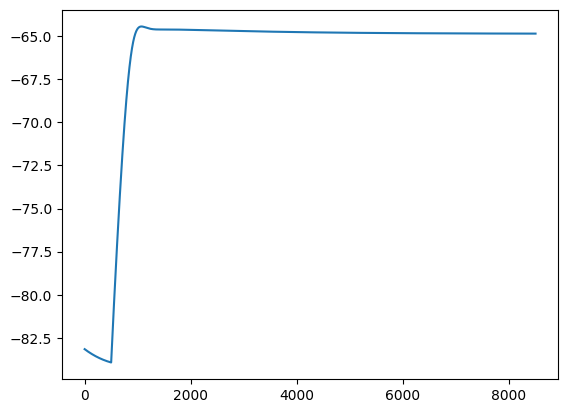

In [45]:
# One random simulation
plt.plot(v_single[0])

In [46]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], include_H=False)


n_params = 3_000

def predict(params):
    inv_params = inv_transform_params(params)
    simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0], include_H=False)[0][0]
    return v

vmapped_predict = jax.vmap(predict)
x_pred = vmapped_predict(opt_params)

_ = np.random.seed(0)
noise = np.random.randn(len(v_data[0])) * 1e-2

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

v_data_spikes = find_spikes(v_data[0] + noise, None, None, thr)
v_data_ss = {
    "spike_count": spike_count(v_data_spikes),
    "first_spike_time": first_spike_time(v_data_spikes),
    "second_spike_time": second_spike_time(v_data_spikes),
    "first_spike_amp": first_spike_amp(v_data[0], v_data_spikes),
    "second_spike_amp": second_spike_amp(v_data[0], v_data_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_pred, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_pred, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_pred, pred_spikes)]
    ),
}

errors = {}
for key in v_data_ss.keys():
    errors[key] = np.abs(v_data_ss[key] - pred_ss[key])

# Weigh the individusal errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)


vmapped_scaled_dtw_loss = jax.vmap(get_scaled_loss, in_axes=(None, 0, None, None))
scaled_dtw_errors = vmapped_scaled_dtw_loss(v_data[0], x_pred, 1.0, 0.05)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [47]:
summed_errors[:100]

array([397.15860097, 876.40625   , 876.40625   , 549.59669175,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 535.73401696,
       876.40625   , 876.40625   , 563.51487618, 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 262.47350208,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 540.63829463, 876.40625   , 245.8291335 ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 347.70728119,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40

In [48]:
count = jnp.sum(summed_errors < 876.40625)
print(count, "spiking models found")

448 spiking models found


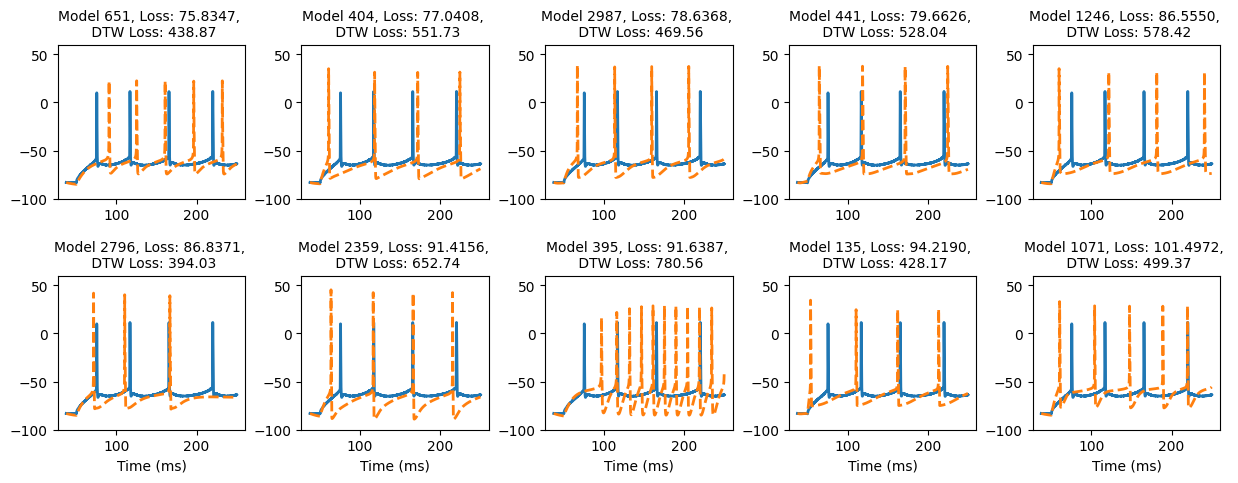

In [51]:
# 10 best results based on summed errors
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

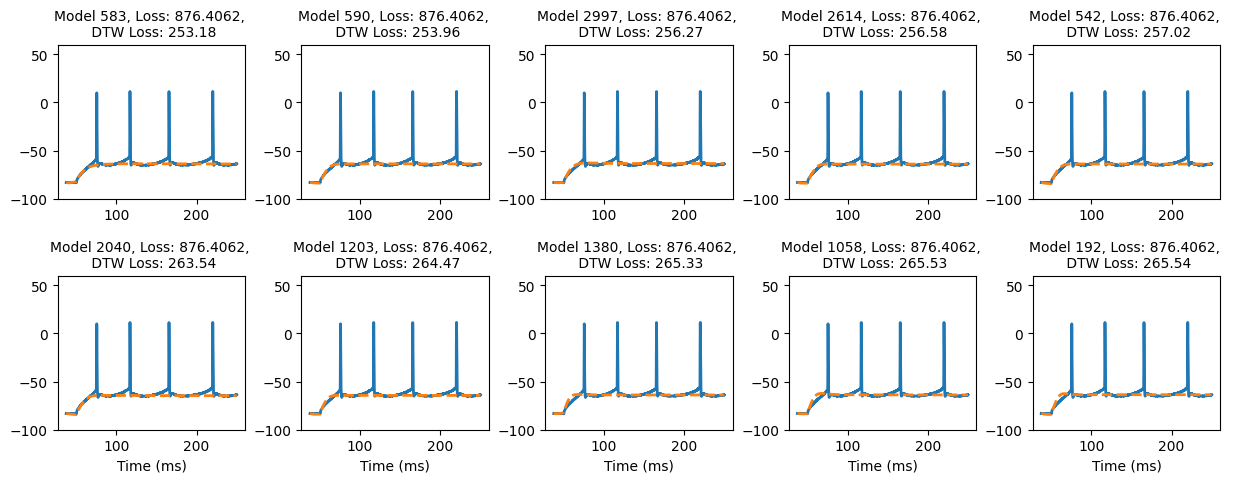

In [52]:
# 10 best results based on dtw loss
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

**Single-compartment model without H() and M() channels**

In [53]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], include_H = False, include_M=False)
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0], include_H = False, include_M = False)[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


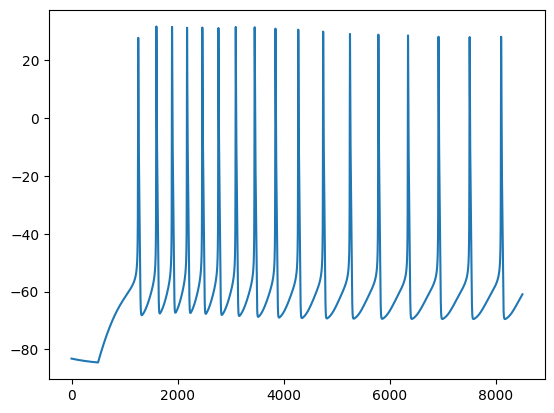

In [54]:
# One random simulation
plt.plot(v_single[0])

In [55]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], include_H=False, include_M = False)

n_params = 3_000

def predict(params):
    inv_params = inv_transform_params(params)
    simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0], include_H=False, include_M=False)[0][0]
    return v

vmapped_predict = jax.vmap(predict)
x_pred = vmapped_predict(opt_params)

_ = np.random.seed(0)
noise = np.random.randn(len(v_data[0])) * 1e-2

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

v_data_spikes = find_spikes(v_data[0] + noise, None, None, thr)
v_data_ss = {
    "spike_count": spike_count(v_data_spikes),
    "first_spike_time": first_spike_time(v_data_spikes),
    "second_spike_time": second_spike_time(v_data_spikes),
    "first_spike_amp": first_spike_amp(v_data[0], v_data_spikes),
    "second_spike_amp": second_spike_amp(v_data[0], v_data_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_pred, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_pred, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_pred, pred_spikes)]
    ),
}

errors = {}
for key in v_data_ss.keys():
    errors[key] = np.abs(v_data_ss[key] - pred_ss[key])

# Weigh the individusal errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)


vmapped_scaled_dtw_loss = jax.vmap(get_scaled_loss, in_axes=(None, 0, None, None))
scaled_dtw_errors = vmapped_scaled_dtw_loss(v_data[0], x_pred, 1.0, 0.05)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [56]:
summed_errors[:100]

array([408.58466895, 876.40625   , 876.40625   , 286.2655293 ,
       157.71490392, 876.40625   , 876.40625   , 876.40625   ,
       531.75488827, 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 188.84983725, 876.40625   , 186.49075322,
       876.40625   , 176.94252386, 369.76100219, 241.18825224,
       876.40625   , 876.40625   , 876.40625   , 306.21054631,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 315.28034045, 876.40625   , 262.0225204 ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 246.69182356, 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       305.47698487, 876.40625   , 216.14744206, 224.47478787,
       876.40625   , 876.40625   , 876.40625   , 312.51528112,
       876.40625   , 876.40625   , 876.40625   , 235.30

In [57]:
count = jnp.sum(summed_errors < 876.40625)
print(count, "spiking models found")

884 spiking models found


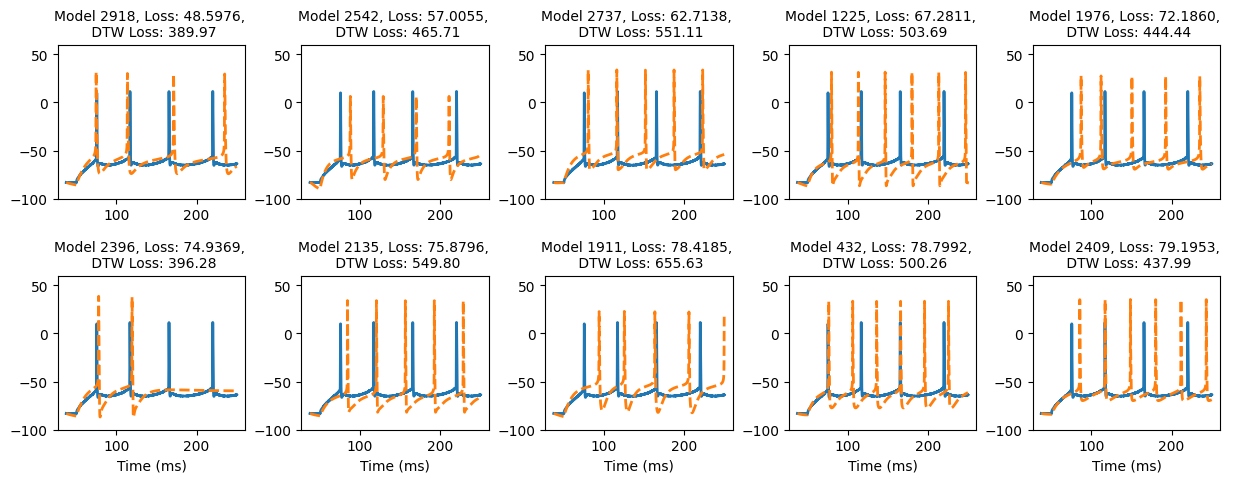

In [58]:
# 10 best results based on summed errors
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

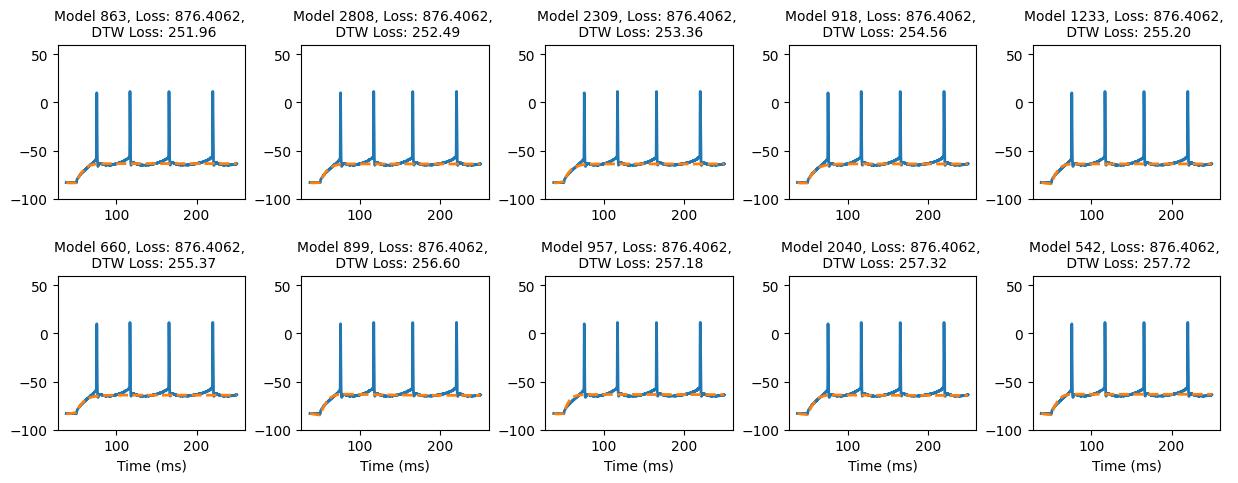

In [59]:
# 10 best results based on dtw loss
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

**Single-compartment model without H(), M() and Calcium-related channels**

In [60]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], include_H = False, include_M=False, include_Ca=False)
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0], include_H = False, include_M = False, include_Ca=False)[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


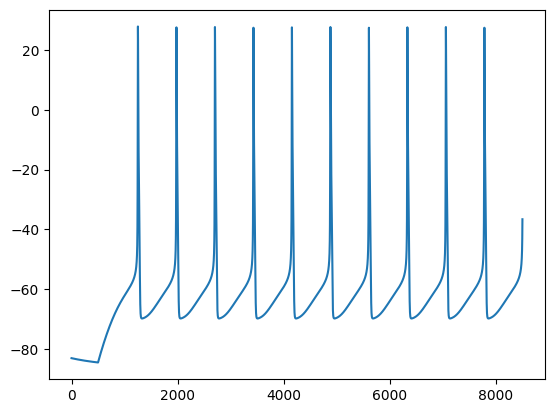

In [61]:
# One random simulation
plt.plot(v_single[0])

In [62]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], include_H=False, include_M = False, include_Ca=False)

n_params = 3_000

def predict(params):
    inv_params = inv_transform_params(params)
    simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0], include_H=False, include_M=False, include_Ca=False)[0][0]
    return v

vmapped_predict = jax.vmap(predict)
x_pred = vmapped_predict(opt_params)

_ = np.random.seed(0)
noise = np.random.randn(len(v_data[0])) * 1e-2

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

v_data_spikes = find_spikes(v_data[0] + noise, None, None, thr)
v_data_ss = {
    "spike_count": spike_count(v_data_spikes),
    "first_spike_time": first_spike_time(v_data_spikes),
    "second_spike_time": second_spike_time(v_data_spikes),
    "first_spike_amp": first_spike_amp(v_data[0], v_data_spikes),
    "second_spike_amp": second_spike_amp(v_data[0], v_data_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_pred, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_pred, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_pred, pred_spikes)]
    ),
}

errors = {}
for key in v_data_ss.keys():
    errors[key] = np.abs(v_data_ss[key] - pred_ss[key])

# Weigh the individusal errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)


vmapped_scaled_dtw_loss = jax.vmap(get_scaled_loss, in_axes=(None, 0, None, None))
scaled_dtw_errors = vmapped_scaled_dtw_loss(v_data[0], x_pred, 1.0, 0.05)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [63]:
summed_errors[:100]

array([409.57016292, 876.40625   , 876.40625   , 273.31088365,
       225.55481989, 876.40625   , 876.40625   , 155.44897202,
       296.24726672, 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 117.30988001, 876.40625   , 238.30767416,
       876.40625   , 178.66057942, 359.46674181, 256.23100289,
       876.40625   , 876.40625   , 196.53478376, 307.41767707,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       876.40625   , 298.43598441, 876.40625   , 200.99971837,
       226.79787277, 876.40625   , 876.40625   , 234.01270267,
       135.06089091, 876.40625   , 209.61378257, 876.40625   ,
       876.40625   , 876.40625   , 304.75033984, 168.71882613,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       144.03111304, 876.40625   , 876.40625   , 876.40625   ,
       305.36194275, 876.40625   , 169.2800832 , 233.02645867,
       876.40625   , 876.40625   , 876.40625   , 264.56735803,
       876.40625   , 876.40625   , 876.40625   , 324.28

In [64]:
count = jnp.sum(summed_errors < 876.40625)
print(count, "spiking models found")

1138 spiking models found


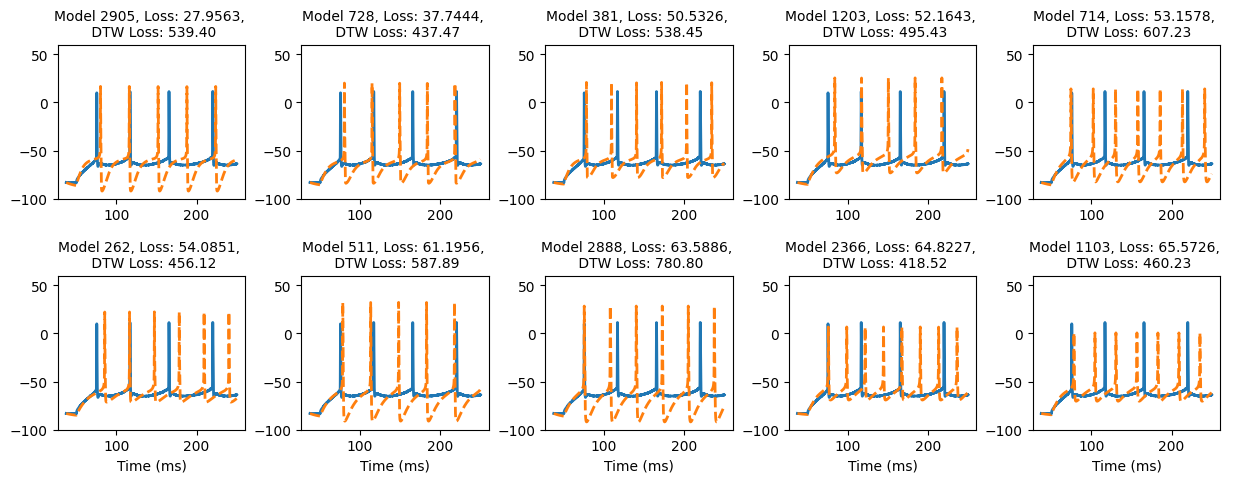

In [65]:
# 10 best results based on summed errors
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

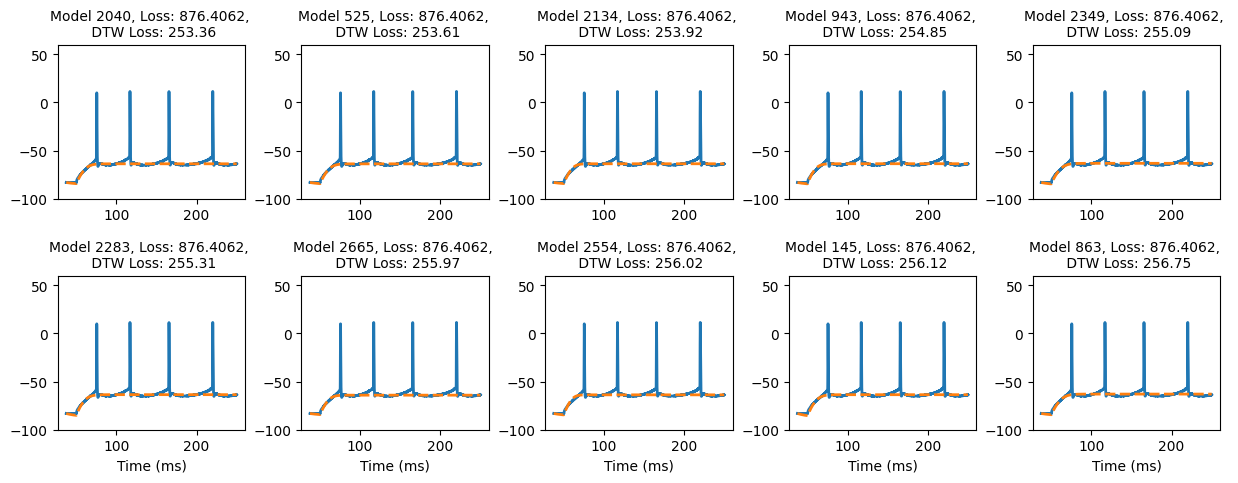

In [66]:
# 10 best results based on dtw loss
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

**Multi-compartment model**

In [67]:
#Define the cell
from voltage_fitting.build_simulator import (
    setup_simulator,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)



all_setup = set_setup(setup)
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_multi = simulate(inv_sampled_params)


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 25


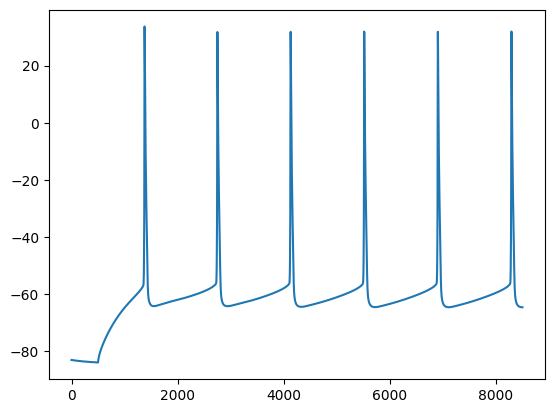

In [68]:
# One random simulation
plt.plot(v_multi[0])

In [69]:
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

n_params = 3_000
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_params)
)

def predict(params):
    inv_params = inv_transform_params(params)
    simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate(inv_params)[0]
    return v

vmapped_predict = jax.vmap(predict)
x_pred_multi = vmapped_predict(opt_params)

_ = np.random.seed(0)
noise = np.random.randn(len(v_data[0])) * 1e-2

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

v_data_spikes = find_spikes(v_data[0] + noise, None, None, thr)
v_data_ss = {
    "spike_count": spike_count(v_data_spikes),
    "first_spike_time": first_spike_time(v_data_spikes),
    "second_spike_time": second_spike_time(v_data_spikes),
    "first_spike_amp": first_spike_amp(v_data[0], v_data_spikes),
    "second_spike_amp": second_spike_amp(v_data[0], v_data_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_pred_multi, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_pred_multi, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_pred_multi, pred_spikes)]
    ),
}

errors = {}
for key in v_data_ss.keys():
    errors[key] = np.abs(v_data_ss[key] - pred_ss[key])

# Weigh the individual errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)


vmapped_scaled_dtw_loss = jax.vmap(get_scaled_loss, in_axes=(None, 0, None, None))
scaled_dtw_errors = vmapped_scaled_dtw_loss(v_data[0], x_pred_multi, 1.0, 0.05)

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [70]:
summed_errors[:100]

array([241.04685472, 876.40625   , 876.40625   , 131.84840551,
        66.17862524, 876.40625   , 876.40625   , 546.04157852,
       876.40625   , 534.44238438, 876.40625   , 876.40625   ,
       876.40625   , 542.47705472, 876.40625   , 200.79472123,
       876.40625   , 100.94838018, 876.40625   , 126.14876947,
       876.40625   , 117.81851406, 178.66202521, 876.40625   ,
       876.40625   , 876.40625   , 876.40625   ,  56.41828085,
        83.97515968, 121.37472979, 876.40625   , 876.40625   ,
       115.62627506,  70.547193  , 514.10774058, 136.25250025,
       876.40625   ,  77.2659309 , 126.46613336, 876.40625   ,
       876.40625   , 876.40625   , 116.00661817, 876.40625   ,
       876.40625   , 876.40625   , 876.40625   , 876.40625   ,
       134.35502702, 876.40625   , 876.40625   , 574.44081198,
        89.70521914, 876.40625   , 171.02703563, 198.46466301,
       876.40625   , 876.40625   , 876.40625   , 152.82939546,
       876.40625   , 876.40625   , 876.40625   ,  93.96

In [71]:
count = jnp.sum(summed_errors < 876.40625)
print(count, "spiking models found")

1169 spiking models found


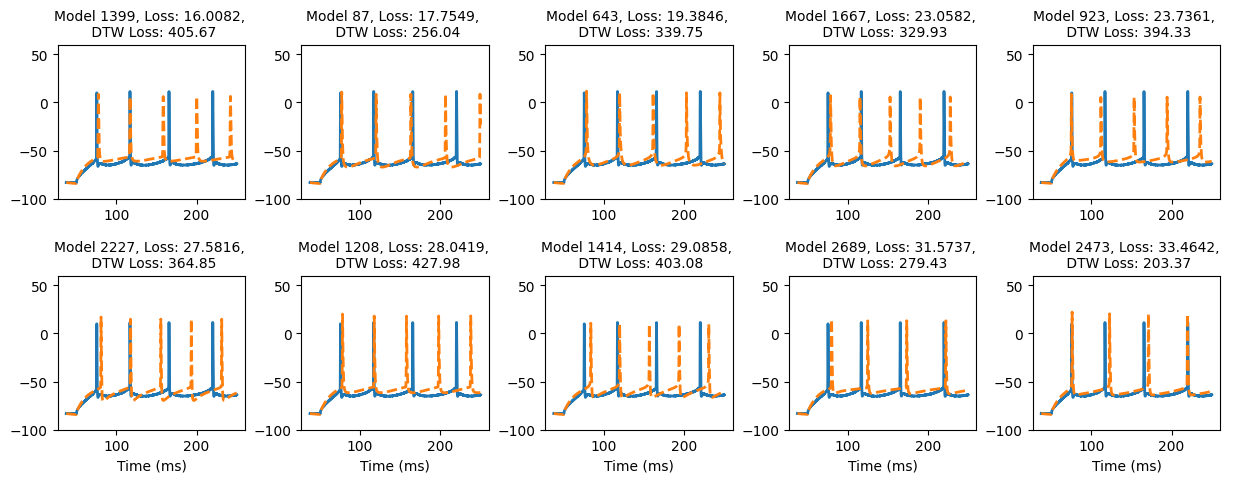

In [72]:
# 10 best results based on summed errors
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred_multi[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

np.save("../results/multi_summed_errors.npy", summed_errors)
np.save("../results/multi_preds.npy", x_pred_multi)

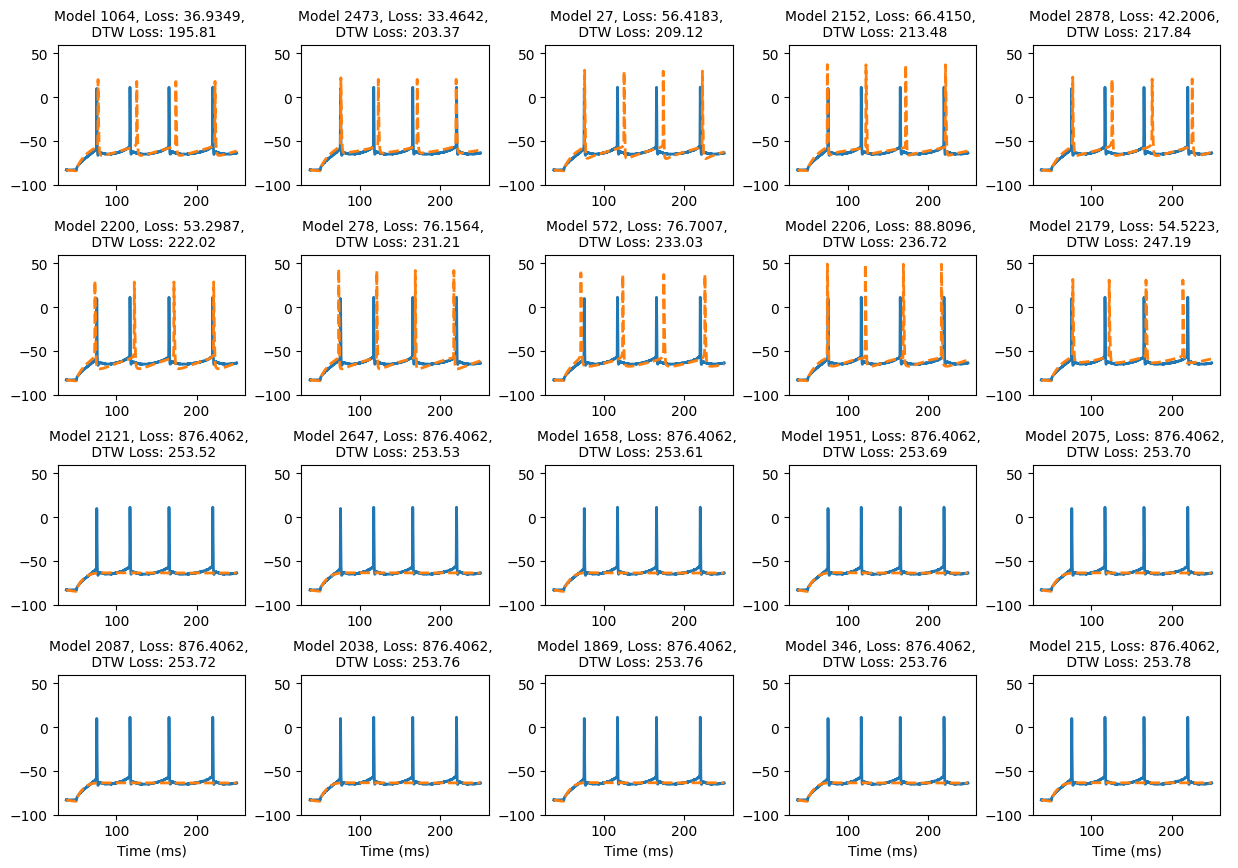

In [73]:
# 10 best results based on dtw loss
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(4,5, figsize = (15,10))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(4):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred_multi[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[3,j].set_xlabel("Time (ms)")

np.save("../results/multi_dtw_errors.npy", scaled_dtw_errors)

**Okay, so the single-comp models are just not good enough at initialization, they are too different from the multi-comp (and the experimental) ones. Can we solve this by scaling down the conductances? But with what values?**

In [84]:
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)


n_params = 3_000
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_params)
)

def predict(params):
    inv_params = inv_transform_params(params)
    inv_params = inv_params.at[5].set(inv_params[5] / 10)
    inv_params = inv_params.at[6].set(inv_params[6] / 10)
    inv_params = inv_params.at[7].set(inv_params[7] / 10)
    inv_params = inv_params.at[8].set(inv_params[8] / 10)
    inv_params = inv_params.at[9].set(inv_params[9] / 10)
    inv_params = inv_params.at[10].set(inv_params[10] / 10)
    inv_params = inv_params.at[12].set(inv_params[12] / 10)
    simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0])[0][0]
    return v

vmapped_predict = jax.vmap(predict)
x_pred_full = vmapped_predict(opt_params)

_ = np.random.seed(0)
noise = np.random.randn(len(v_data[0])) * 1e-2

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

v_data_spikes = find_spikes(v_data[0] + noise, None, None, thr)
v_data_ss = {
    "spike_count": spike_count(v_data_spikes),
    "first_spike_time": first_spike_time(v_data_spikes),
    "second_spike_time": second_spike_time(v_data_spikes),
    "first_spike_amp": first_spike_amp(v_data[0], v_data_spikes),
    "second_spike_amp": second_spike_amp(v_data[0], v_data_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_pred_full, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_pred_full, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_pred_full, pred_spikes)]
    ),
}

errors = {}
for key in v_data_ss.keys():
    errors[key] = np.abs(v_data_ss[key] - pred_ss[key])

# Weigh the individusal errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)

vmapped_scaled_dtw_loss = jax.vmap(get_scaled_loss, in_axes=(None, 0, None, None, None))
scaled_dtw_errors = vmapped_scaled_dtw_loss(v_data[0], x_pred_full, 1.0, 0.05, 1.0)#, cost_fn_power=1.0, scale=0.05, penalty_rate=1.0)
scaled_dtw_errors_squared = vmapped_scaled_dtw_loss(v_data[0], x_pred_full, 2.0, 1.0, 0.0)#, cost_fn_power=2.0, scale=1.0, penalty_rate=0.0)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


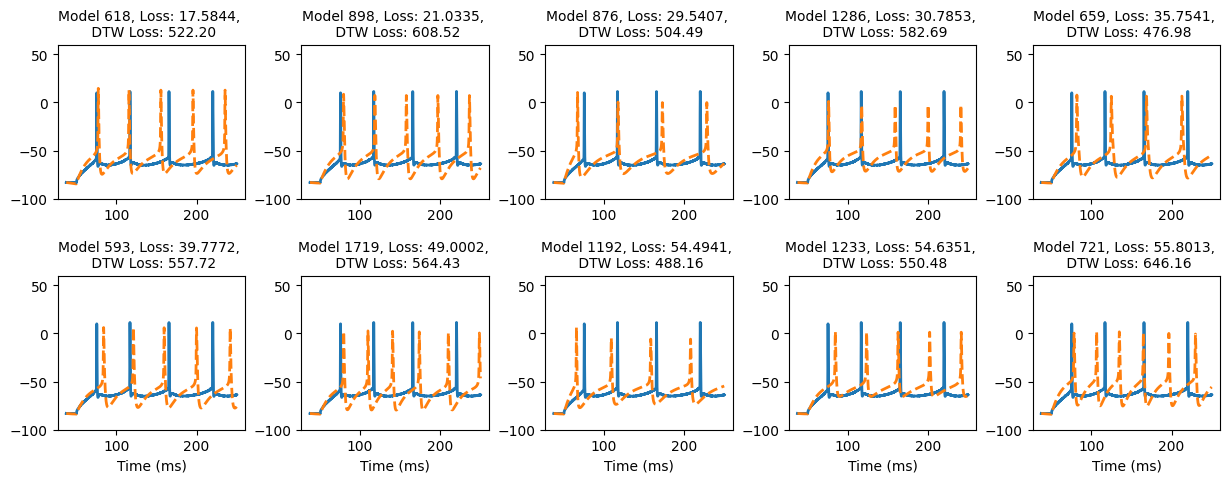

In [85]:
# 10 best results based on summed errors
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred_full[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")

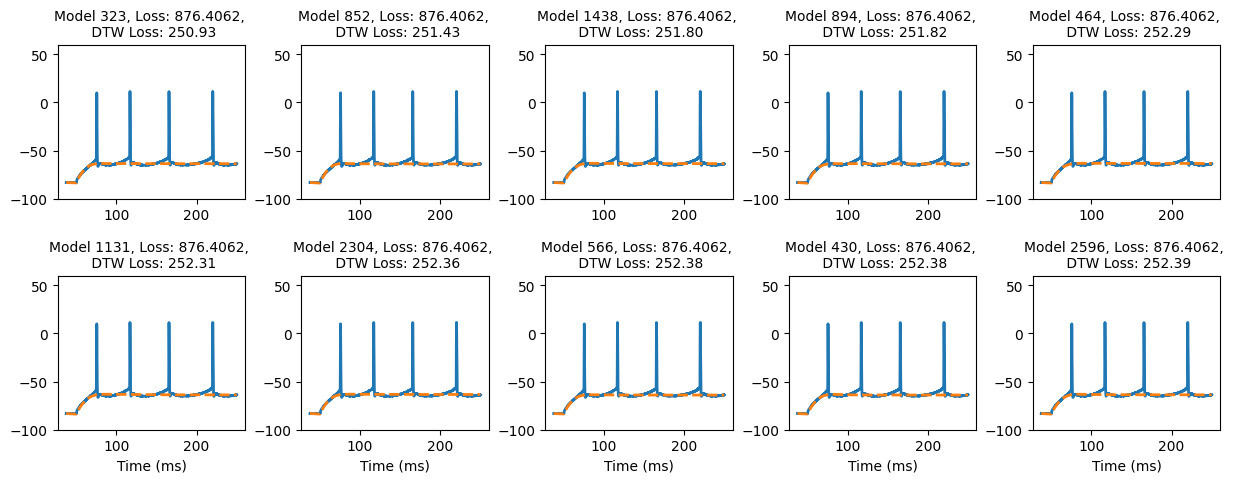

In [86]:
# 10 best results based on dtw loss
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, x_pred_full[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

for j in range(5):
    axs[1,j].set_xlabel("Time (ms)")